In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
data = pd.read_excel("customer_purchase.xlsx", sheet_name="Data")
print(data.shape)
data.head() 

(24, 4)


,Purchasing behaviour,Gender,Age,Time spent in online shop
0,Buy now,female,22,40
1,Buy now,female,25,23
2,Buy now,male,18,12
3,Buy now,male,45,28
4,Buy now,female,12,43


In [3]:
print(data.isnull().sum())

Purchasing behaviour         0
Gender                       0
Age                          0
Time spent in online shop    0
dtype: int64


In [4]:
data["Gender"] = data["Gender"].map({
    "male": 1,
    "female": 0
})
label = LabelEncoder()
data["Purchasing behaviour"] = label.fit_transform(
    data["Purchasing behaviour"]
)
print(data.head()) 

   Purchasing behaviour  Gender  Age  Time spent in online shop
0                     1       0   22                         40
1                     1       0   25                         23
2                     1       1   18                         12
3                     1       1   45                         28
4                     1       0   12                         43


In [5]:
feature_cols = [
    "Gender",
    "Age",
    "Time spent in online shop"
]
X = data[feature_cols]
y = data["Purchasing behaviour"] 

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=5,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (19, 3)
Testing Data  : (5, 3)


In [14]:
model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test) 

In [15]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(conf_mat)
accuracy = metrics.accuracy_score(y_test, y_pred)
print("\nAccuracy Score :", accuracy)
print("Accuracy Percentage :", accuracy * 100)
print("\nClassification Report\n")
print(metrics.classification_report(y_test, y_pred, zero_division=0)) 

Confusion Matrix
[[0 0 1]
 [2 0 0]
 [0 0 2]]

Accuracy Score : 0.4
Accuracy Percentage : 40.0

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.67      1.00      0.80         2

    accuracy                           0.40         5
   macro avg       0.22      0.33      0.27         5
weighted avg       0.27      0.40      0.32         5



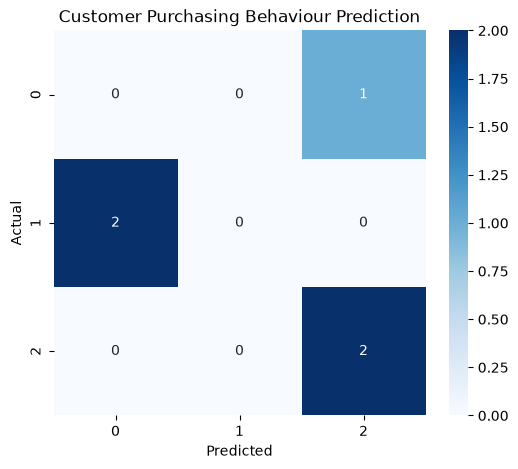

In [16]:
plt.figure(figsize=(6,5))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Customer Purchasing Behaviour Prediction")
plt.show() 

In [17]:
sample = pd.DataFrame(
    [[0, 25, 40]],
    columns=feature_cols
)
prediction = model.predict(sample)
print("Predicted Class :", prediction[0])
print(
    "Predicted Purchasing Behaviour :",
    label.inverse_transform(prediction)[0]
)   

Predicted Class : 1
Predicted Purchasing Behaviour : Buy now
